## testing ground for motif search algorithms

networkx hello world:

In [574]:
G = nx.fast_gnp_random_graph(10, 0.4, seed=12)
H = nx.fast_gnp_random_graph(5, 0.7, seed=14)
# nx.draw_spring(G, with_labels=True)

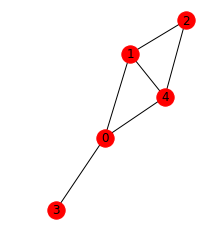

In [437]:
plt.subplot(121)
nx.draw_spring(H, with_labels=True)

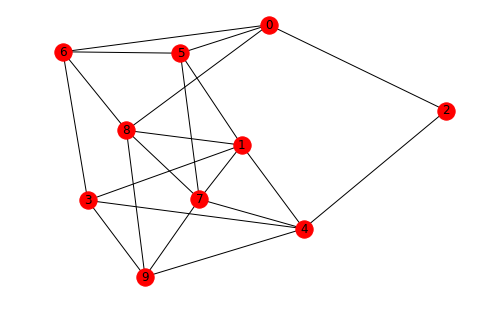

In [350]:
# plt.subplot(121)
nx.draw_spring(G, with_labels=True)

In [ ]:
H2 = nx.Graph()
H2.add_nodes_from([0,1,2,3,4,5])
H2.add_edges_from([(0,1), (1, 2), (2, 0), (4, 3), (3, 5), (5, 4), (0, 3)])
nx.draw_spring(H2, with_labels=True)

## CONSOLE

In [ ]:
import numpy as np
import pandas as pd
import networkx as nx
import functions as fn
import matplotlib.pyplot as plt
import importlib
import numpy.lib.recfunctions as rfn
importlib.reload(fn)
G = nx.fast_gnp_random_graph(10, 0.4, seed=12)
H = nx.fast_gnp_random_graph(5, 0.7, seed=14)

######################################################################

instances = fn.findSubgraphInstances(H, G, False)
[k.getMap() for k in instances]

In [ ]:
f1 = fn.Map([(0, 0), (1, 1), (2, 2), (3, 3), (4, 4), (5, 5)])
f2 = fn.Map([(0, 0), (1, 1), (2, 2), (3, 3), (4, 5), (5, 4)])
f3 = fn.Map([(0, 0), (1, 2), (2, 1), (3, 3), (4, 4), (5, 5)])
f4 = fn.Map([(0, 0), (1, 2), (2, 1), (3, 3), (4, 5), (5, 4)])
f5 = fn.Map([(0, 3), (1, 4), (2, 5), (3, 0), (4, 1), (5, 2)])
f6 = fn.Map([(0, 3), (1, 5), (2, 4), (3, 0), (4, 2), (5, 1)])

autH2 = [f1, f2, f3, f4, f5, f6]  # set of automorphisms of H2
eq = fn.findEquivalenceClasses(autH2)
M = fn.symmetryConditions(autH2)

[t for t in f1.getMap()]

## Flipping graph edges

The two graphs $F = (V_F, E_F)$ and $F2 = (V_{F2}, E_{F2})$ below are edge-inverses of each other:

$V_F = V_{F2}$ 

$(u, v) \in E_F \iff (u, v) \notin E_{F2}$

I was wondering what would happen to the 3-core of a graph if the edges were flipped in this way. I made some plots to see the relation between average coreness of a graph and its edge-inverse, shown below.

{8: {'coreness': 2, 'layer': 2},
 2: {'coreness': 3, 'layer': 3},
 7: {'coreness': 3, 'layer': 4},
 9: {'coreness': 3, 'layer': 4},
 3: {'coreness': 3, 'layer': 5},
 5: {'coreness': 3, 'layer': 5},
 0: {'coreness': 3, 'layer': 6},
 1: {'coreness': 3, 'layer': 6},
 4: {'coreness': 3, 'layer': 6},
 6: {'coreness': 3, 'layer': 6}}

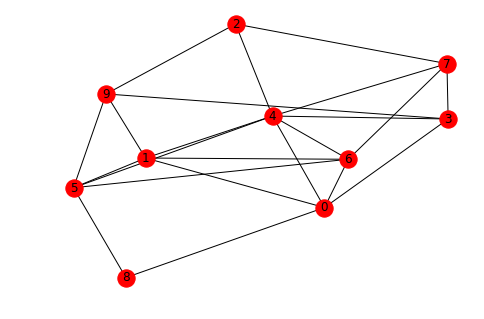

In [1341]:
F = nx.fast_gnp_random_graph(10, 0.5, seed = 1)
nx.draw_spring(F, with_labels=True)
fn.onionDecompose(F)

{4: {'coreness': 2, 'layer': 2},
 0: {'coreness': 4, 'layer': 3},
 1: {'coreness': 4, 'layer': 3},
 5: {'coreness': 4, 'layer': 3},
 6: {'coreness': 4, 'layer': 3},
 9: {'coreness': 4, 'layer': 3},
 2: {'coreness': 4, 'layer': 4},
 3: {'coreness': 4, 'layer': 4},
 7: {'coreness': 4, 'layer': 4},
 8: {'coreness': 4, 'layer': 4}}

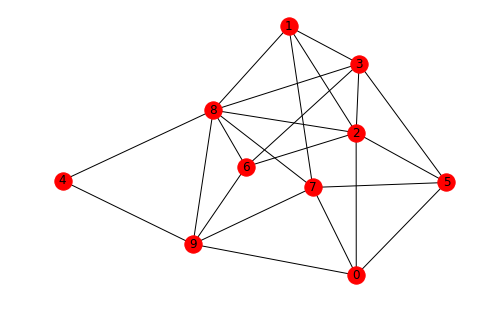

In [1344]:
F = nx.fast_gnp_random_graph(10, 0.5, seed = 1)

F2 = nx.Graph()
F2.add_nodes_from(F.nodes())
F2.add_edges_from([i for i in nx.non_edges(F)])
nx.draw_spring(F2, with_labels=True)
fn.onionDecompose(F2)

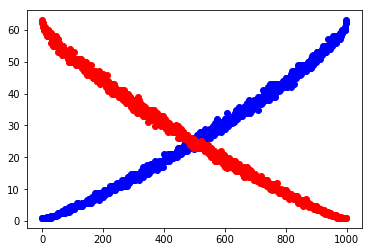

In [1323]:
# for k in [8, 16, 32, 64, 128]:

import matplotlib.pyplot as plt

k = 64
m = 1000
x_axis = range(m)
graphCoreness = np.zeros(m)
flippedCoreness = np.zeros(m)

for i in x_axis:
    F = nx.fast_gnp_random_graph(k, i/m)
    F2 = nx.Graph()
    F2.add_nodes_from(F.nodes())
    F2.add_edges_from([j for j in nx.non_edges(F)])
    
    od_F = fn.onionDecompose(F)
    od_F2 = fn.onionDecompose(F2)
    
    graphCoreness[i] = np.average([k['coreness'] for k in od_F.values()])
    flippedCoreness[i] = np.average([k['coreness'] for k in od_F2.values()])

plt.plot(x_axis, graphCoreness, 'bo', x_axis, flippedCoreness, 'ro')
plt.show()

In [1339]:
a = np.zeros([3,3])
a

array([[0., 0., 0.],
       [0., 0., 0.],
       [0., 0., 0.]])